In [94]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import os
os.chdir("/Users/mike_/OneDrive/Escritorio")

In [95]:
data_kc = pd.read_csv("kc_house_data.csv")
data_kc

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [96]:
data_kc = data_kc[["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "view", "condition", "grade", "sqft_above", "sqft_basement", "yr_built", "yr_renovated", "lat", "long", "sqft_living15", "sqft_lot15"]]
print(data_kc.shape)
data_kc.head()


(21613, 18)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


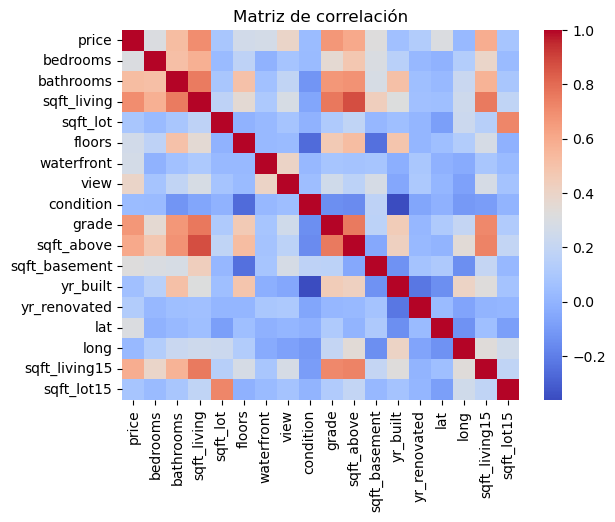

In [69]:
#Documentar explícitamente el proceso de selección de variables (criterio estadístico observable):


In [70]:
#Para la selección de variables independientes se realizó un análisis exploratorio utilizando una matriz de correlación entre las variables del dataset kc_house_data.
#Se priorizaron aquellas variables con mayor correlación respecto al precio (price), debido a que estas aportan mayor capacidad explicativa al modelo.

#Por ejemplo:

#sqft_living → alta correlación positiva con el precio (tamaño habitable impacta valor inmobiliario).

#grade → refleja calidad de construcción, variable relevante en valuación.

#bathrooms / bedrooms → influyen en funcionalidad y valor de mercado.

#lat / location variables → reflejan efecto ubicación.

#Asimismo, se evitó incluir variables altamente correlacionadas entre sí para reducir problemas de multicolinealidad: 
#Se observó alta correlación entre variables relacionadas con el tamaño y calidad de la vivienda (sqft_living, grade, sqft_above).. se elimino 
#la variable sqft_above por alta correlación (.87).

#Variables eliminadas por baja relevancia estadística:
# CONDITION : Presenta baja correlación con el precio y su efecto queda parcialmente explicado por la variable grade, que refleja mejor la calidad de construcción.
# YR_RENOVATED: Tiene una alta proporción de valores cero y muestra poca relación con el precio, por lo que su capacidad explicativa es limitada.
#FLOORs: Se observa baja correlación con el precio.
#SQFT_LOT: Seobserva baja correlación con el precio e inicialmente arrojo un p-value de .118 



data_kc[["sqft_above","sqft_living"]].corr()

,sqft_above,sqft_living
sqft_above,1.000000,0.876597
sqft_living,0.876597,1.000000


In [101]:
data_kc["Intercepto"] = 1
data_kc = data_kc[["Intercepto", "price", "bedrooms", "bathrooms", "sqft_living", "waterfront", "view", "grade","sqft_basement", "yr_built", "lat", "long", "sqft_living15", "sqft_lot15"]]
print(data_kc.shape)
data_kc.head()




(21613, 14)


,Intercepto,price,bedrooms,bathrooms,sqft_living,waterfront,view,grade,sqft_basement,yr_built,lat,long,sqft_living15,sqft_lot15
0,1,221900.0,3,1.00,1180,0,0,7,0,1955,47.5112,-122.257,1340,5650
1,1,538000.0,3,2.25,2570,0,0,7,400,1951,47.7210,-122.319,1690,7639
2,1,180000.0,2,1.00,770,0,0,6,0,1933,47.7379,-122.233,2720,8062
3,1,604000.0,4,3.00,1960,0,0,7,910,1965,47.5208,-122.393,1360,5000
4,1,510000.0,3,2.00,1680,0,0,8,0,1987,47.6168,-122.045,1800,7503


In [102]:
Xdata = data_kc[["Intercepto", "bedrooms", "bathrooms", "sqft_living", "waterfront", "view", "grade","sqft_basement", "yr_built", "lat", "long", "sqft_living15", "sqft_lot15"]].values
Ydata = data_kc[["price"]].values

    

In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(Xdata, Ydata, test_size = 0.30, random_state = 1)

In [104]:
X = X_train
Y = Y_train

In [105]:
X.shape[0]

15129

In [106]:
X.shape[1]

13

In [107]:
np.set_printoptions(formatter={'float_kind':'{:f}'.format})

In [108]:
#Mostrar el desarrollo formal del modelo usando notación y cálculo matricial:

# Modelo en forma matricial:
# y = Xβ + ε
# β = (XᵀX)^(-1) Xᵀ y
#
# Donde:
# X: matriz (n x p) con columna de intercepto y variables independientes
# y: vector (n x 1) con la variable dependiente (price)
# β: vector (p x 1) de coeficientes

In [109]:
XT_X = np.matmul(np.matrix.transpose(X), X)
XT_X

array([[15129.000000, 50963.000000, 32017.000000, 31442387.000000,
        116.000000, 3505.000000, 115894.000000, 4424997.000000,
        29820815.000000, 719521.906700, -1848966.397000, 30017402.000000,
        193331191.000000],
       [50963.000000, 184941.000000, 113274.250000, 113202849.000000,
        372.000000, 12596.000000, 396101.000000, 16753940.000000,
        100513486.000000, 2423751.361100, -6228097.770000,
        104817301.000000, 662133752.000000],
       [32017.000000, 113274.250000, 76568.375000, 74367338.750000,
        306.000000, 9001.500000, 254161.750000, 10796334.000000,
        63280042.500000, 1522745.525575, -3912539.223500,
        67932199.250000, 438003499.000000],
       [31442387.000000, 113202849.000000, 74367338.750000,
        77688746971.000000, 358581.000000, 10127227.000000,
        253007293.000000, 11781400252.000000, 62104027960.000000,
        1495470821.007197, -3842211452.765000, 69386164211.000000,
        471674253298.000000],
       [11

In [110]:
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[83.740389, -0.004325, 0.014357, -0.000022, 0.005888, 0.006686,
        0.025843, 0.000033, -0.001445, -0.154411, 0.602571, -0.000039,
        -0.000001],
       [-0.004325, 0.000122, -0.000037, -0.000000, 0.000060, 0.000010,
        0.000020, -0.000000, 0.000000, 0.000029, -0.000016, 0.000000,
        0.000000],
       [0.014357, -0.000037, 0.000339, -0.000000, -0.000010, -0.000006,
        -0.000027, -0.000000, -0.000003, -0.000047, 0.000056, 0.000000,
        0.000000],
       [-0.000022, -0.000000, -0.000000, 0.000000, -0.000000, 0.000000,
        -0.000000, -0.000000, 0.000000, 0.000000, -0.000000, -0.000000,
        -0.000000],
       [0.005888, 0.000060, -0.000010, -0.000000, 0.010463, -0.000496,
        0.000032, 0.000000, 0.000000, 0.000064, 0.000078, 0.000000,
        0.000000],
       [0.006686, 0.000010, -0.000006, 0.000000, -0.000496, 0.000160,
        -0.000015, -0.000000, 0.000000, 0.000058, 0.000084, -0.000000,
        -0.000000],
       [0.025843, 0.000020, -0.0

In [111]:
XT_Y = np.matmul(np.matrix.transpose(X), Y)
XT_Y

array([[8134792844.000000],
       [28921660282.000000],
       [19344041227.500000],
       [20285899254544.000000],
       [186574092.000000],
       [3471948304.000000],
       [66500354540.000000],
       [3124774008563.000000],
       [16042657850839.000000],
       [387121579186.852905],
       [-994165337864.433350],
       [18255655339721.000000],
       [115936311020042.000000]])

In [112]:
#Presentar la ecuación final del modelo con coeficientes interpretables:

#Price = -3.437×10^7 - 3.006×10^4(bedrooms) + 4.387×10^4(bathrooms) + 173.917(sqft_living) + 0.082(sqft_lot)
#+ 5.782×10^5(waterfront) + 4.847×10^4(view) + 9.754×10^4(grade) - 30.796(sqft_basement) - 2764.012(yr_built) 
#+ 5.619×10^5(lat) - 1.021×10^5(long) + 22.484(sqft_living15) - 0.312(sqft_lot15)

In [113]:
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[-34157343.302856],
       [-30138.283029],
       [43880.581729],
       [174.280314],
       [577876.427635],
       [48562.936302],
       [97606.738263],
       [-30.996428],
       [-2768.901879],
       [561291.457511],
       [-100720.900784],
       [22.100516],
       [-0.223501]])

In [114]:
TSS = np.matmul(np.matrix.transpose(Y), Y) - len(Y) *  (Y.mean()**2)
TSS
ESS = np.matmul(np.matmul(np.matrix.transpose(betas), np.matrix.transpose(X)), np.matmul(X, betas)) - len(Y)* (Y.mean)()**2
ESS
RSS = TSS - ESS
RSS
RSq = 1 - RSS / TSS
RSq
RSqAj = 1 - (RSS / (X.shape[0] - X.shape[1])) / (TSS / X.shape[0] - 1)
RSqAj





array([[0.696534]])

In [115]:
import statsmodels.api as sm
regressor = sm.OLS(Y, X).fit()
print(regressor.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     2895.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:49:35   Log-Likelihood:            -2.0576e+05
No. Observations:               15129   AIC:                         4.116e+05
Df Residuals:                   15116   BIC:                         4.117e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.416e+07   1.79e+06    -19.117      0.0

In [116]:
#La significancia estadística de las variables se evaluó mediante los p-values del modelo OLS (columna P>|t|). 
#Se observó que todas las variables presentan p-values menores a 0.05, indicando significancia estadística. 

#Depuración del modelo: 
#En la primer corrida variable x4 mostró un p-value de 0.118, por lo que se elimino en un proceso de depuración adicional.


#Los p-values se utilizaron para evaluar la significancia individual de las variables,
#mientras que el R² ajustado permitió evaluar la calidad global del modelo. 
#La combinación de ambos criterios permitió identificar variables potencialmente no relevantes sin afectar 
#significativamente la capacidad explicativa del modelo.

In [117]:
Y_pred = np.matmul(X_test, betas)
Y_pred

array([[656718.851789],
       [443836.874916],
       [736095.456639],
       ...,
       [356018.916945],
       [2193169.868538],
       [761177.086188]], shape=(6484, 1))

In [118]:
Resid = Y_test - Y_pred
Resid

array([[-197718.851789],
       [1163.125084],
       [320904.543361],
       ...,
       [-126018.916945],
       [-513169.868538],
       [-468177.086188]], shape=(6484, 1))

array([[<Axes: title={'center': '0'}>]], dtype=object)

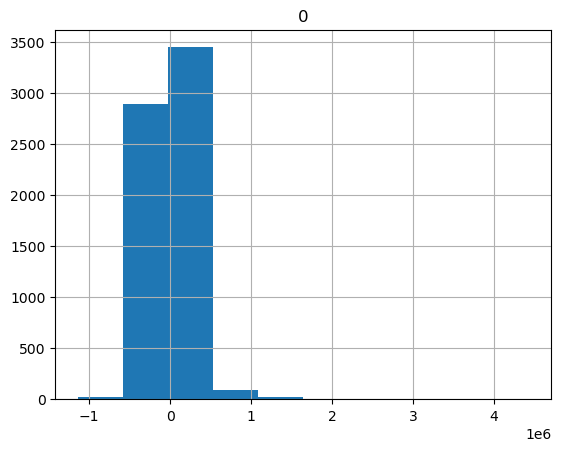

In [119]:
df = pd.DataFrame(Resid)
df.hist()

In [120]:
from sklearn.metrics import r2_score
from sklearn import metrics

print("Coeficiente r2", r2_score(Y_test, Y_pred))




Coeficiente r2 0.6836496101908418


In [121]:
#Comparar claramente resultados manuales vs. reporte automatizado y justificar diferencias:

# Diferencia máxima entre betas manuales y statsmodels
diff = np.max(np.abs(betas.flatten() - regressor.params))
print("Diferencia máxima:", diff)


Diferencia máxima: 0.3781615048646927


In [122]:
d = betas.flatten() - regressor.params
idx = np.argmax(np.abs(d))
print("Índice con mayor diferencia:", idx)
print("Manual:", betas.flatten()[idx])
print("Statsmodels:", regressor.params[idx])
print("Diferencia:", d[idx])

Índice con mayor diferencia: 0
Manual: -34157343.302856445
Statsmodels: -34157342.92469494
Diferencia: -0.3781615048646927


In [123]:
#Comparar claramente resultados manuales vs. reporte automatizado y justificar diferencias:

#Los coeficientes calculados manualmente con β = (XᵀX)⁻¹Xᵀy coinciden con los obtenidos en statsmodels. 
#La diferencia máxima (0.38) solo aparece en el intercepto y corresponde a un error numérico muy pequeño (≈10⁻⁸ relativo), 
#atribuible al redondeo en la inversión de la matriz XᵀX.